# Project 1: Marketing Outcome Prediction

The purpose of this project is to explore the relationship between three platforms of advertising expenditure and the sales, and build the regression model and predicting the sales.

## 1. Data Preparation

### 1.1 Import and preview the data

In [1]:
import pandas as pd

df = pd.read_csv("data/Dummy Data HSS.csv")
display(df.head(10))

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
5,29.0,9.614382,1.027163,Mega,105.889148
6,55.0,24.893811,4.273602,Micro,198.679825
7,31.0,17.355042,2.289855,Nano,108.733932
8,76.0,24.648898,7.130116,Macro,270.189400
9,13.0,0.431128,2.229423,Mega,48.280582


### 1.2 Inspect the data

General Information of the Dataset

In [2]:
columns = df.columns
print("Dataset Shape: \n", df.shape)
print("---------------------------------------------------------\n")
print("Dataset Info: \n")
print(df.info())
print("---------------------------------------------------------\n")
print("Dataset Describe: \n", df.describe())

Dataset Shape: 
 (4572, 5)
---------------------------------------------------------

Dataset Info: 

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   str    
 4   Sales         4566 non-null   float64
dtypes: float64(4), str(1)
memory usage: 178.7 KB
None
---------------------------------------------------------

Dataset Describe: 
                 TV        Radio  Social Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.00

### 1.3 Handling Missing Values

Checking missing values:

In [3]:
print("Missing Count: \n", df.isnull().sum())
print("---------------------------------------------------------\n")
print("Missing Value Ratio: \n", df.isnull().mean())
print("---------------------------------------------------------\n")
print("Missing Value Rows: ", df.isnull().any(axis = 1).sum())

Missing Count: 
 TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64
---------------------------------------------------------

Missing Value Ratio: 
 TV              0.002187
Radio           0.000875
Social Media    0.001312
Influencer      0.000000
Sales           0.001312
dtype: float64
---------------------------------------------------------

Missing Value Rows:  26


Since the missing value ratio for different column are all relatively small, in order to fairly compare the three regression models, it is better to keep the same sample size for three platforms. Dropping all rows containing missing values will be more effective and accurate than replacing the missing value with artificially filled values.

Handling missing values

In [4]:
columns = ["TV","Radio","Social Media","Sales"]
df_cleaned = df.dropna(subset=columns).copy()
display(df_cleaned.head(5))

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


Compare before and after:

In [5]:
print("Before Shape:", df.shape)
print("After Shape:", df_cleaned.shape)
print("Remaining Missing Value Rows:", df_cleaned.isnull().any(axis = 1).sum())

Before Shape: (4572, 5)
After Shape: (4546, 5)
Remaining Missing Value Rows: 0


### 1.4 Other Quality Checks

Check duplicate rows:

In [6]:
print("Duplicate rows:", df_cleaned.duplicated().sum())

Duplicate rows: 0


Check value range:

In [7]:
print("Minimum values: ")
print(df_cleaned[columns].min())
print("---------------------------------------------------------\n")
print("Negative values: ")
print((df_cleaned[columns]<0).sum())

Minimum values: 
TV              10.000000
Radio            0.000684
Social Media     0.000031
Sales           31.199409
dtype: float64
---------------------------------------------------------

Negative values: 
TV              0
Radio           0
Social Media    0
Sales           0
dtype: int64


## 2. Regression Analysis

Preview the data after cleaning:

In [8]:
df_model = df_cleaned[columns].copy()
display(df_model.head(5))

,TV,Radio,Social Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


### 2.1 Determining correlation


#### 2.1.1 Scatter plots

In order to explore the correlation between two variables when one of them is related to the other in some way. The scatter plot is useful to help to visualize the patterns of the paired values. Therefore, a scatter plot will be developed and analyzed for each of the advertising platform in the next sections.

Model 1: TV vs Sales

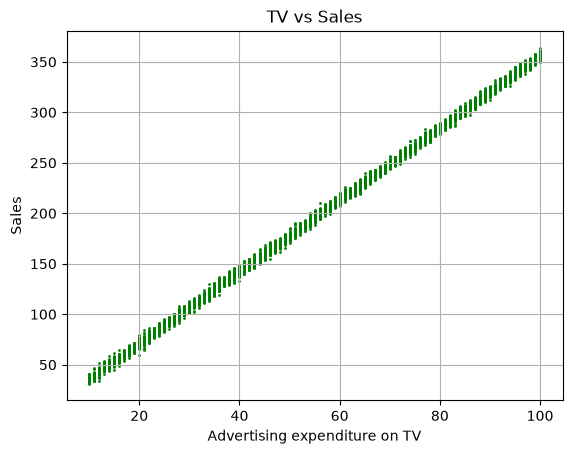

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x=df_model['TV'],y=df_model['Sales'], color='green', s=1)

plt.xlabel("Advertising expenditure on TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.grid()

plt.show()

These data points are almost arranged along a straight line from the lower left to the upper right corner, indicating that there is positive linear relationship between TV and Sales.

Model 2: Radio vs Sales

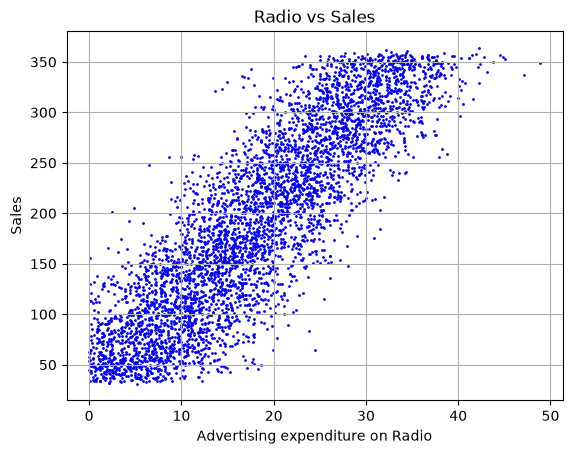

In [10]:
plt.scatter(x=df_model['Radio'],y=df_model['Sales'], color='blue', s=1)

plt.xlabel("Advertising expenditure on Radio")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.grid()

plt.show()

Similar data arrangement as the previous. However, the Radio vs Sales plot shows more widely pointed scattered, revealing that within same advertising expenditure on radio there may be various amount of Sales so that Radio may have a weaker linear relationship with sales. Further regression analysis is needed to compare their slopes and predictive performance.

Model 3: Social Media vs Sales

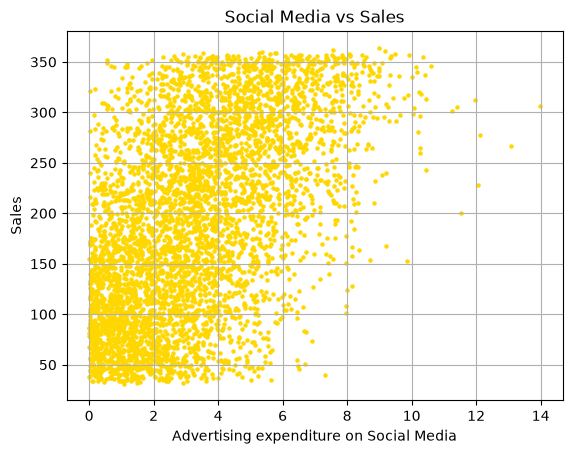

In [11]:
plt.scatter(x=df_model['Social Media'],y=df_model['Sales'], color='gold', s=5)

plt.xlabel("Advertising expenditure on Social Media")
plt.ylabel("Sales")
plt.title("Social Media vs Sales")
plt.grid()

plt.show()

The points on the scatter plots almost follow a straight line pattern from the bottom left corner to top right corner, but the trend is not as clear as the previous two plots. The Social Media vs Sales plot shows even more widely pointed scattered than Radio. This should still be verified by further evaluation.

#### 2.1.2 Correlation Calculation with Pearson's Correlation Score

In [12]:
import scipy
tv_r=scipy.stats.pearsonr(df_model['TV'], df_model['Sales']).correlation
print(f"Pearson's r={tv_r}")

radio_r=scipy.stats.pearsonr(df_model['Radio'], df_model['Sales']).correlation
print(f"Pearson's r={radio_r}")

social_media_r=scipy.stats.pearsonr(df_model['Social Media'], df_model['Sales']).correlation
print(f"Pearson's r={social_media_r}")


Pearson's r=0.9994973659385122
Pearson's r=0.8686378124591716
Pearson's r=0.5274464187714509


Scale: -1 <= r <= 1

|Marketing channel | Pearson's Correlation Score | Interpretation|
|---|---|---|
|TV| 0.9995| Extremely strong positive|
|Radio| 0.8686| Strong positive|
|Social Media| 0.5274| Moderate positive|

The Pearson's r value indicates that TV appears to be the strongest individual linear predictor of Sales.

### 2.2 Least Squares Regression
Since all previous three plots show linear relationship, Ordinary Least Squares regression model is being used.

Formula:  ***Y = Slope X + Intercept***

In [13]:
import statsmodels.api as sm

#### Model 1: TV vs Sales

In [14]:
tv_x_train = df_model['TV'].tolist()
y_train = df_model['Sales'].tolist()
tv_x = sm.add_constant(tv_x_train)
tv_result = sm.OLS(y_train, tv_x).fit()
print(tv_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:58:44   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [15]:
print("TV Slope:", tv_result.params[1])
print("TV Intercept:", tv_result.params[0])

TV Slope: 3.561514094641168
TV Intercept: -0.13249254000209848


Visualization

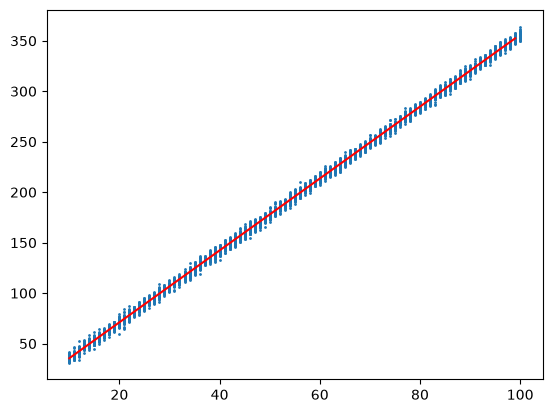

In [16]:
import numpy as np
max_x = df_model['TV'].max()
min_x = df_model['TV'].min()
x_range = np.arange(min_x, max_x, 1)

y_predicted = tv_result.params[1] * x_range + tv_result.params[0]

plt.scatter(tv_x_train, y_train, s=1)
plt.plot(x_range,y_predicted, 'r')
plt.show()

Root Mean Squared Error (RMSE)

In [17]:
actual_sales = np.array(y_train)
predicted_sales = tv_result.predict(tv_x)
tv_rmse = np.sqrt(np.mean((actual_sales - predicted_sales) ** 2))
print("TV RMSE", tv_rmse)

TV RMSE 2.9485897228065294


Important Information:
|Indicator|Value|Interpretation|
|---|---|---|
|R-squared|0.999|The model can explain 99.9% of the variance in the Sales|
|Slope|3.562|The slope of the best fit straight line|
|Intercept|-0.132|The intercept calculated by the model|
|RMSE|2.949|The root mean square prediction error within the sample of the TV Regression Model is apx. 2.949 million

#### Model 2: Radio vs Sales

In [18]:
radio_x_train = df_model['Radio'].tolist()
y_train = df_model['Sales'].tolist()
radio_x = sm.add_constant(radio_x_train)
radio_result = sm.OLS(y_train, radio_x).fit()
print(radio_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                 1.397e+04
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:58:45   Log-Likelihood:                -23864.
No. Observations:                4546   AIC:                         4.773e+04
Df Residuals:                    4544   BIC:                         4.774e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.5868      1.455     27.890      0.0

In [19]:
print("Radio Slope:", radio_result.params[1])
print("Radio Intercept:", radio_result.params[0])

Radio Slope: 8.361627710036128
Radio Intercept: 40.58680021541979


Visualization

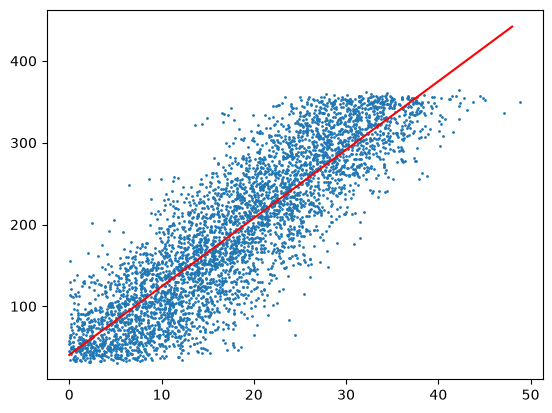

In [20]:
import numpy as np
max_x = df_model['Radio'].max()
min_x = df_model['Radio'].min()
x_range = np.arange(min_x, max_x, 1)

y_predicted = radio_result.params[1] * x_range + radio_result.params[0]

# plotting the data and the regression line
plt.scatter(radio_x_train, y_train, s=1)
plt.plot(x_range,y_predicted, 'r')
plt.show()

Root Mean Squared Error (RMSE)

In [21]:
actual_sales = np.array(y_train)
predicted_sales = radio_result.predict(radio_x)
radio_rmse = np.sqrt(np.mean((actual_sales - predicted_sales) ** 2))
print("Radio RMSE", radio_rmse)

Radio RMSE 46.08140625204434


Important Information:
|Indicator|Value|Interpretation|
|---|---|---|
|R-squared|0.755|The model can explain 75.5% of the variance in the Sales|
|Slope|8.362|The slope of the best fit straight line|
|Intercept|40.587|The intercept calculated by the model|
|RMSE|46.081|The root mean square prediction error within the sample of the Radio Regression Model is apx. 46.081 million

#### Model 3: Social Media vs Sales

In [22]:
social_media_x_train = df_model['Social Media'].tolist()
y_train = df_model['Sales'].tolist()
social_media_x = sm.add_constant(social_media_x_train)
social_media_result = sm.OLS(y_train, social_media_x).fit()
print(social_media_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     1751.
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:58:45   Log-Likelihood:                -26315.
No. Observations:                4546   AIC:                         5.263e+04
Df Residuals:                    4544   BIC:                         5.265e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        118.6726      2.116     56.074      0.0

In [23]:
print("Social Media Slope:", social_media_result.params[1])
print("Social Media Intercept:", social_media_result.params[0])

Social Media Slope: 22.18786282220418
Social Media Intercept: 118.67257233365552


Visualization

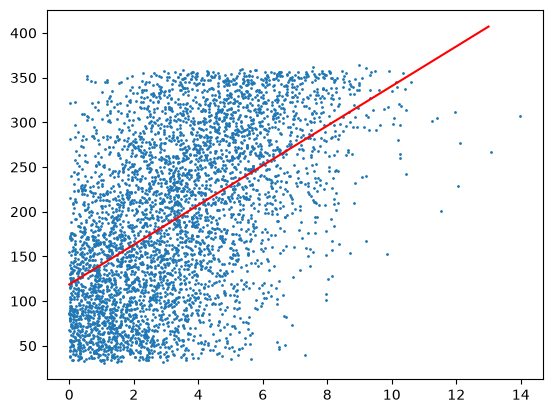

In [24]:
import numpy as np
max_x = df_model['Social Media'].max()
min_x = df_model['Social Media'].min()
x_range = np.arange(min_x, max_x, 1)

y_predicted = social_media_result.params[1] * x_range + social_media_result.params[0]

plt.scatter(social_media_x_train, y_train, s=1)
plt.plot(x_range,y_predicted, 'r')
plt.show()

Root Mean Squared Error (RMSE)

In [25]:
actual_sales = np.array(y_train)
predicted_sales = social_media_result.predict(social_media_x)
social_media_rmse = np.sqrt(np.mean((actual_sales - predicted_sales) ** 2))
print("Social Media RMSE", social_media_rmse)

Social Media RMSE 79.01990317286443


Important Information:
|Indicator|Value|Interpretation|
|---|---|---|
|R-squared|0.278|The model can explain 27.8% of the variance in the Sales|
|Slope|22.188|The slope of the best fit straight line|
|Intercept|118.673|The intercept calculated by the model|
|RMSE|79.020|The root mean square prediction error within the sample of the Social Media Regression Model is apx. 79.020 million

### 2.3 Multiple Linear Regression

By now, the relationship between each advertising platform and Sales have been analyzed, however, TV, Radio, and Social Media in the original dataset exist simultaneously in the same record. A multiple linear regression model is used to explore the relationship between Sales and all three advertising expenditures together.

Formula:  ***Y = $Slope_1$ $X_1$ + $Slope_2$ $X_2$ + $Slope_3$ $X_3$ + Intercept***

In [26]:
final_x_train = df_model[['TV','Radio','Social Media']]
y_train = df_model['Sales'].tolist()
final_x = sm.add_constant(final_x_train)
final_result = sm.OLS(y_train, final_x).fit()
print(final_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.505e+06
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:58:45   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4542   BIC:                         2.277e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1340      0.103     -1.303   

Root Mean Squared Error (RMSE)

In [27]:
actual_sales = np.array(y_train)
predicted_sales = final_result.predict(final_x)
final_rmse = np.sqrt(np.mean((actual_sales - predicted_sales) ** 2))
print("Multiple Regression Model RMSE", final_rmse)

Multiple Regression Model RMSE 2.9485350404425974


***Sales = 3.5626(TV) - 0.0040(Radio) + 0.0050(Social Media) - 0.1340***

The multiple linear regression model has an R-squared value of ***0.999***. TV has the coefficient value of ***3.5626***, Radio has ***-0.0040***, and Social Media has ***0.0050***. This means although Radio and Social Media are positively correlated with Sales in simple linear regression model, TV itself captured almost all the linear information related to Sales within this dataset in multiple linear regression model. The multiple regression model indicates that the RMSE is ***2.9485***, which is similar to the TV simple regression model, this also prove that adding Radio and Social Media does not improve the goodness of fit much.

### 2.4 Visual Diagnostics: Residual Plot

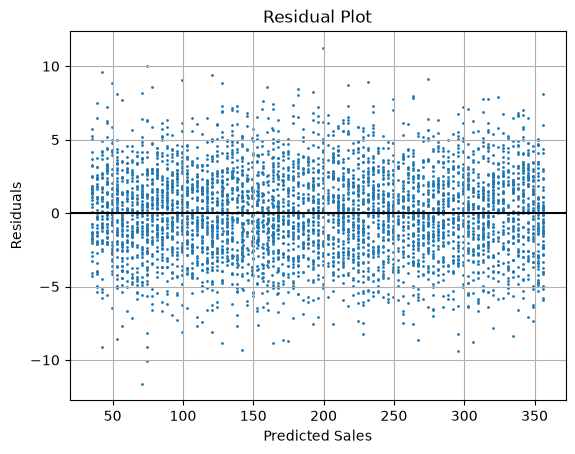

In [28]:
final_predicted = final_result.predict(final_x)
final_residuals = final_result.resid
plt.scatter(final_predicted, final_residuals, s=1)
plt.axhline(y = 0, color = 'black')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()

plt.show()


This residual plot shows that residuals are randomly scattered around zero which means there are no obvious error patterns. It helps to identify that the model chosen is appropriate.